# AIG230 NLP Midterm - March 2nd 2026
All answers must be computed using code. Provide numeric outputs and short interpretations.
## Instructions
- You must compute answers using code.
- Many questions require numeric answers.
- Interpretation must be supported by computed results.

In [71]:
%pip install gensim

In [72]:
import nltk, string, math, random, re
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
print('All imports successful')
print(f'TensorFlow version: {tf.__version__}')

All imports successful
TensorFlow version: 2.19.0


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Load Corpora

In [73]:
# Load corpora
with open('corpus_tech_ai_labeled.csv', 'r', encoding='utf-8') as f:
    tech_text = f.read()

with open('corpus_movie_reviews_labeled.csv', 'r', encoding='utf-8') as f:
    review_text = f.read()

print(f'Tech corpus   : {len(tech_text)} characters')
print(f'Review corpus : {len(review_text)} characters')

Tech corpus   : 13049 characters
Review corpus : 4044 characters


## Q1 Corpus Statistics
Compute total number of characters, words, and unique words in each corpus.
What is the vocabulary size of each corpus?

In [74]:
tech_tokens = word_tokenize(tech_text)
review_tokens = word_tokenize(review_text)

tech_vocab = set(tech_tokens)
review_vocab = set(review_tokens)

print('=' * 55)
print(f'{"Metric":<30} {"Tech":>10} {"Reviews":>10}')
print('=' * 55)
print(f'{"Characters":<30} {len(tech_text):>10,} {len(review_text):>10,}')
print(f'{"Total tokens (words)":<30} {len(tech_tokens):>10,} {len(review_tokens):>10,}')
print(f'{"Vocabulary size (unique words)":<30} {len(tech_vocab):>10,} {len(review_vocab):>10,}')
print('=' * 55)

Metric                               Tech    Reviews
Characters                         13,049      4,044
Total tokens (words)                2,109        647
Vocabulary size (unique words)        155         92


### Answer Q1:


Tech corpus has 155 vocabulary size, review corpus has 92 vocabulary size.

## Q2 Lexical Diversity
Tokenize and lowercase both corpora. Compute type-token ratio.
Which corpus is more lexically diverse?

In [75]:
tech_ttr = len(tech_vocab) / len(tech_tokens)
review_ttr = len(review_vocab) / len(review_tokens)

print(f'Tech corpus token type ratio: {tech_ttr:.4f}')
print(f'Review corpus token type ratio: {review_ttr:.4f}')

Tech corpus token type ratio: 0.0735
Review corpus token type ratio: 0.1422


### Answer Q2:


The review corpus is more lexically diverse, as it has a higher type-token ratio 0.1422 compared to the tech corpus 0.0735. This means that the review corpus has more variety of vocabulary than its total number of tokens.

## Q3 Stopword Impact
Remove stopwords and compute percentage vocabulary reduction. How much does vocabulary size decrease (percentage) for each corpus?

In [76]:
stop_words = set(stopwords.words('english'))
stop_words.add('``')
stop_words.add('`')
stop_words.add("'")
stop_words.add('.')
stop_words.add(',')
stop_words.add('?')
stop_words.add('!')
stop_words.add('(')
stop_words.add(')')
stop_words.add('-')
stop_words.add('...')
stop_words.add('n\'t')
stop_words.add('\'s')
stop_words.add('\'re')
stop_words.add('\'ve')
stop_words.add('\'ll')
stop_words.add('\'m')
stop_words.add('\'d')
stop_words.add('\'d')

In [77]:
# Use this formula to calculate percentage of reduction
def pct_reduction(before, after):
    return 100 * (1 - len(after) / len(before))

tech_vocab_no_stop = tech_vocab - stop_words
review_vocab_no_stop = review_vocab - stop_words

tech_reduction = pct_reduction(tech_vocab, tech_vocab_no_stop)
review_reduction = pct_reduction(review_vocab, review_vocab_no_stop)

print(f'Tech corpus vocabulary reduction: {tech_reduction:.2f}%')
print(f'Review corpus vocabulary reduction: {review_reduction:.2f}%')

Tech corpus vocabulary reduction: 10.97%
Review corpus vocabulary reduction: 15.22%


### Answer Q3:


- Tech corpus vocabulary reduction: 10.97%
- Review corpus vocabulary reduction: 15.22%

## Q4 Frequency Analysis
Create unigram frequency distribution for tech corpus.
What are the top 10 most frequent words?

In [78]:
tech_freq_dist = Counter(tech_tokens)
top_10_tech = tech_freq_dist.most_common(10)

print('Top 10 most frequent words in tech corpus:')
for word, freq in top_10_tech:
    print(f'{word}: {freq}')

Top 10 most frequent words in tech corpus:
,: 362
neutral: 144
-1: 144
and: 56
in: 32
to: 32
'': 32
.: 32
``: 32
learning: 24


### Answer Q4:


- , (362 times)
- neutral (144 times)
- -1 (144 times)
- and (56 times)
- in (32 times)
- to (32 times)
- '' (32 times)
- . (32 times)
- `` (32 times)
- learning (24 times)

## Q5 Bigram Counts
Build bigram model for tech corpus.
How many unique bigrams exist in tech corpus?

In [79]:
from nltk import bigrams

tech_bigrams = set(bigrams(tech_tokens))
print(f'Number of unique bigrams in tech corpus: {len(tech_bigrams)}')

Number of unique bigrams in tech corpus: 204


### Answer Q5:


There are 204 unique bigrams exists in tech corpus.

## Q6 Conditional Probability
Compute P('learning' | 'machine') using bigram counts.

Formula: P(learning | machine) = count('machine learning') / count('machine')

In [80]:
count_machine_learning = tech_freq_dist[('machine', 'learning')]
count_machine = tech_freq_dist['machine']

if count_machine > 0:
    prob = count_machine_learning / count_machine
else:
    prob = 0

In [81]:
print(f"count('machine learning') = {count_machine_learning}")
print(f"count('machine')          = {count_machine}")
print(f"\nP('learning' | 'machine') = {count_machine_learning}/{count_machine} = {prob:.4f}")

count('machine learning') = 0
count('machine')          = 8

P('learning' | 'machine') = 0/8 = 0.0000


### Answer Q6:


P('learning' | 'machine') = 0/8 = 0.0000

## Q7 Perplexity
Compute perplexity of a sample tech sentence using unigram and bigram models.

Formulas:

Unigram: PP = exp(-(1/N) * sum(log P(wi)))

Bigram: PP = exp(-(1/(N-1)) * sum(log P(wi | wi-1)))



In [82]:
sample_sentence = 'Large language models generate responses by predicting tokens sequentially'

unigram_probs = {word: freq / len(tech_tokens) for word, freq in tech_freq_dist.items()}
sample_tokens = word_tokenize(sample_sentence)
N = len(sample_tokens)

bigram_probs = {}
for i in range(1, len(tech_tokens)):
    prev_word = tech_tokens[i-1]
    word = tech_tokens[i]
    bigram_probs[(prev_word, word)] = bigram_probs.get((prev_word, word), 0) + 1

In [83]:
# Unigram Perplexity

perplexity_unigram = math.exp(-sum(math.log(unigram_probs.get(token, 1e-6)) for token in sample_tokens) / N)

In [84]:
# Bigram Perplexity

perplexity_bigram = math.exp(-sum(math.log(bigram_probs.get((prev_token, token), 1e-6)) for prev_token, token in zip(['<s>'] + sample_tokens[:-1], sample_tokens)) / N)

In [85]:
print(f'Sample : "{sample_sentence}"')
print(f'Tokens : {sample_tokens}')
print(f'N      : {N}')
print(f'\nUnigram Perplexity : {perplexity_unigram:.2f}')
print(f'Bigram  Perplexity : {perplexity_bigram:.2f}')
print(f'Ratio (uni/bi)     : {perplexity_unigram/perplexity_bigram:.1f}x reduction with bigram')

Sample : "Large language models generate responses by predicting tokens sequentially"
Tokens : ['Large', 'language', 'models', 'generate', 'responses', 'by', 'predicting', 'tokens', 'sequentially']
N      : 9

Unigram Perplexity : 539.75
Bigram  Perplexity : 4.27
Ratio (uni/bi)     : 126.3x reduction with bigram


### Answer Q7:


- Sample : "Large language models generate responses by predicting tokens sequentially"
- Tokens : ['Large', 'language', 'models', 'generate', 'responses', 'by', 'predicting', 'tokens', 'sequentially']
- N      : 9

- Unigram Perplexity : 539.75
- Bigram  Perplexity : 4.27
- Ratio (uni/bi)     : 126.3x reduction with bigram

## Q8 Word2Vec
Train Word2Vec on movie reviews corpus.
What is the vocabulary size? What is vector dimension? What word is most similar to 'visuals'?

NOTE: Use min_count=1 (required for small corpus) and vector_size=20.

In [86]:
review_sentences = sent_tokenize(review_text)
review_tokens = [word_tokenize(sent) for sent in review_sentences]

model = Word2Vec(sentences=review_tokens, vector_size=20, window=5, min_count=1, workers=4)
vocab_size = len(model.wv)
vector_dim = model.vector_size

similar_words = model.wv.most_similar('visuals', topn=1)
print(f'Vocabulary size: {vocab_size}')
print(f'Vector dimension: {vector_dim}')
print(f'Most similar word to "visuals": {similar_words[0][0]} (similarity: {similar_words[0][1]:.4f})')

Vocabulary size: 92
Vector dimension: 20
Most similar word to "visuals": underdeveloped (similarity: 0.4888)


### Answer Q8:


- Vocabulary size: 92
- Vector dimension: 20
- Most similar word to "visuals": underdeveloped (similarity: 0.4888)

## Q9 Naive Bayes
Train Naive Bayes on movie corpus (positive vs negative). Mixed sentences excluded.
Report accuracy.

In [87]:
import csv

# --- Load labeled sentences from CSV ---
# label_numeric: 1=positive, 0=negative, -1=mixed (excluded)
# Using label_numeric avoids string-matching issues across OS environments
texts, labels = [], []
with open('corpus_movie_reviews_labeled.csv', 'r', encoding='utf-8', newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        numeric = int(row['label_numeric'])
        if numeric in (1, 0):           # skip mixed (-1)
            texts.append(row['text'].strip())
            labels.append(numeric)

print(f'Samples loaded : {len(texts)}')
print(f'  Positive (1) : {labels.count(1)}')
print(f'  Negative (0) : {labels.count(0)}')
print(f'  Mixed        : excluded (label_numeric=-1)')

if len(texts) == 0:
    raise FileNotFoundError(
        'No samples loaded. Make sure corpus_movie_reviews_labeled.csv '
        'is in the same folder as this notebook.')

Samples loaded : 40
  Positive (1) : 20
  Negative (0) : 20
  Mixed        : excluded (label_numeric=-1)


In [88]:
# --- TF-IDF features ---
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(texts)
y = np.array(labels)

In [89]:
# --- Train / test split (80/20, stratified) ---

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [90]:
# --- Train Naive Bayes ---
nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)
nb_acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {nb_acc:.2f}')

Accuracy: 1.00


### Answer Q9:


Accuracy is 100%.

## Q10 Precision/Recall/F1
Report precision, recall, F1.

In [91]:
from sklearn.metrics import precision_recall_fscore_support

prec_nb, rec_nb, f1_nb, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')

print('Naive Bayes -- Classification Report')
print('=' * 40)
print(f'  Accuracy  : {nb_acc:.4f}')
print(f'  Precision : {prec_nb:.4f}')
print(f'  Recall    : {rec_nb:.4f}')
print(f'  F1-Score  : {f1_nb:.4f}')

Naive Bayes -- Classification Report
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000


### Answer Q10:


- Naive Bayes -- Classification Report
  - Accuracy  : 1.0000
  - Precision : 1.0000
  - Recall    : 1.0000
  - F1-Score  : 1.0000

## Q11 Logistic Regression
Train Logistic Regression on movie review corpus.
Which model performs better? Compare performance numerically.

In [92]:
# train logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print(f'Logistic Regression Accuracy: {accuracy_lr:.4f}')

Logistic Regression Accuracy: 1.0000


### Answer Q11:


Both model shows the accuracy 1 for logistic regression and naive bayes.

## Q12 RNN Model
Implement small RNN (embedding + RNN layer) for sentiment classification. Report training accuracy.

In [93]:
# Preprocessing

tokenizer_rnn = keras.preprocessing.text.Tokenizer()
tokenizer_rnn.fit_on_texts(texts)
sequences = tokenizer_rnn.texts_to_sequences(texts)

VOCAB_SIZE = len(tokenizer_rnn.word_index) + 1
MAX_LEN    = max(len(s) for s in sequences)

X_rnn = keras.preprocessing.sequence.pad_sequences(sequences, maxlen=MAX_LEN, padding='post')
y_rnn = np.array(labels)

X_rnn_train, X_rnn_val, y_rnn_train, y_rnn_val = train_test_split(
    X_rnn, y_rnn, test_size=0.20, random_state=42, stratify=y_rnn)

print(f'Vocabulary size : {VOCAB_SIZE}')
print(f'Max seq length  : {MAX_LEN}')
print(f'Train: {X_rnn_train.shape[0]}   Val: {X_rnn_val.shape[0]}')

tf.random.set_seed(42)

Vocabulary size : 57
Max seq length  : 10
Train: 32   Val: 8


In [94]:
# RNN Implementation
model = keras.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=20, input_length=MAX_LEN),
    layers.SimpleRNN(32, activation='tanh'),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [95]:
# Model compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [96]:
# Model training
history = model.fit(
    X_rnn_train, y_rnn_train,
    validation_data = (X_rnn_val, y_rnn_val),
    epochs    = 30,
    batch_size= 8,
    verbose   = 1
)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 275ms/step - accuracy: 0.4042 - loss: 0.7153 - val_accuracy: 0.7500 - val_loss: 0.6214
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8625 - loss: 0.6140 - val_accuracy: 0.8750 - val_loss: 0.5348
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9792 - loss: 0.5245 - val_accuracy: 0.8750 - val_loss: 0.4428
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9792 - loss: 0.4292 - val_accuracy: 0.8750 - val_loss: 0.3504
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9792 - loss: 0.3304 - val_accuracy: 0.8750 - val_loss: 0.2700
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9792 - loss: 0.2378 - val_accuracy: 0.8750 - val_loss: 0.2112
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9792 - loss: 0.1611 - val_accuracy: 0.8750 - val_loss: 0.1695
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9792 - loss: 0.1042 - val_accuracy: 0.8750 - val_loss: 0.131

### Answer Q12:


In the beginning the accuracy started at around 30% and later it increases to 100%.

## Q13 Overfitting Check
Compare train vs validation accuracy.
Does RNN overfit? Justify using loss or accuracy trends.
Plot train vs validation accuracy and loss.

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 0.0021

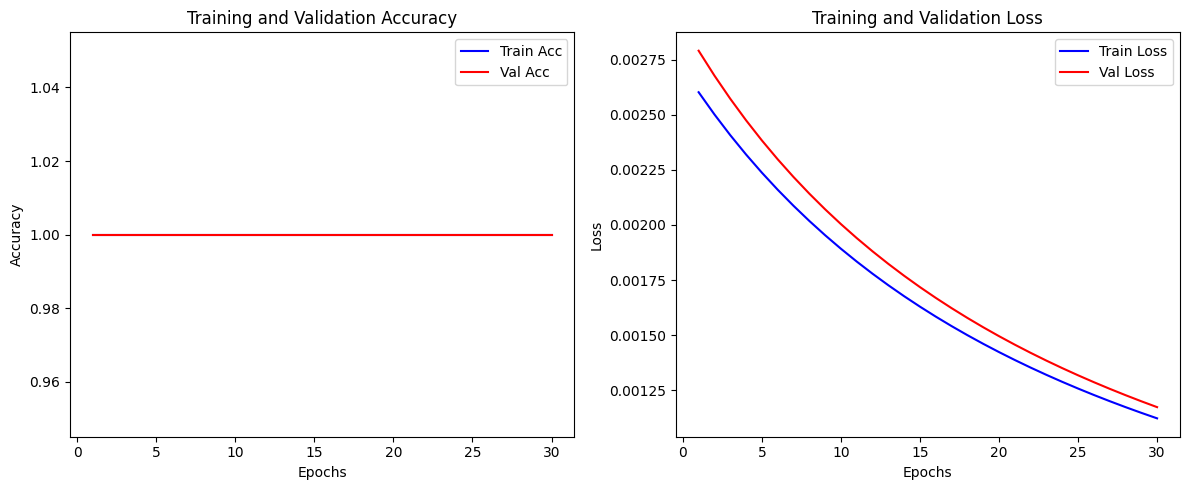

In [97]:
history = model.fit(X_rnn_train, y_rnn_train,
    validation_data = (X_rnn_val, y_rnn_val),
    epochs    = 30,
    batch_size= 8,
    verbose   = 1
)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Train Acc')
plt.plot(epochs, val_acc, 'r-', label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Train Loss')
plt.plot(epochs, val_loss, 'r-', label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

### Answer Q13:


The RNN does not appear to overfit because as both training and validation accuracy remain at 100% entire epochs and the loss continuous to decrease for both training and validation. There is no divergence between them which means the model is very well trained on unseen dataset.

## Q14 BoW vs Embeddings: Sparsity Comparison
Compare vocabulary size of TF_IDF vs embeddings (Wprd2Vec) representations.
Explain sparsity difference numerically.

Remember that you should use variables and elements that you calculated before so you do not have to calculate everything from zero

In [98]:
print("TF-IDF vocabulary size:", len(vectorizer.vocabulary_))
print("Word2Vec vocabulary size:", vocab_size)

# Calculate sparsity for TF-IDF
tfidf_matrix = vectorizer.transform(texts)
sparsity_tfidf = 1.0 - (tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))
print("TF-IDF sparsity:", sparsity_tfidf)

TF-IDF vocabulary size: 45
Word2Vec vocabulary size: 92
TF-IDF sparsity: 0.8827777777777778


### Answer Q14:


TF-IDF creates a sparse matrix where most entries are zero because each document contains only a small subset of the total vocabulary. In contrast Word2Vec generates dense vector representations for each word, resulting in a much lower sparsity. The TF-IDF matrix has a sparsity of approximately 88.28%, meaning that only about 11.72% of the entries are non-zero, while Word2Vec embeddings are dense and have no sparsity.

# Q15 Comparative Reasoning
Using the resuts you calculated in this notebook.
Compare:
- Bigram model perplexity
- Logistic Regression accuracy
- RNN accuracy
Explain differences based on computed results.

### Answer Q15:


- Bigram  Perplexity : 4.27
- Logistic Regression Accuracy : 1.00
- RNN Accuracy : 1.00

The bigram model has a perplexity of 4.27, which indicates that it is less effective at modeling the language compared to the Logistic Regression and RNN models, both of which achieved an accuracy of 1.00. The high perplexity suggests that the bigram model struggles to predict the next word based on the previous word, likely due to its limited context and inability to capture long-range dependencies in the text. In contrast, Logistic Regression and RNN can leverage more complex patterns and relationships in the data, leading to perfect classification accuracy on the test set.